# Body-Fat Model Training and Final Evaluation

This notebook trains the final ordinal classifier and three class-specific
hybrid regressors. A fixed 2,000-row holdout is isolated before thresholds,
scalers, or models are fitted. Final evidence reports classifier accuracy,
each regressor's MAE, and the MAE of the complete routed pipeline.

`ordinal class -> class-specific Lasso base + neural residual -> body-fat percentage`

In [1]:
import hashlib
import os
import pickle
import platform
import random

from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    mean_absolute_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

## Configuration

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (
            candidate
            / "back_end"
            / "app"
            / "config"
            / "settings.py"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from the Fitness_Proj repository "
        "or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "back_end" / "app" / "ml" / "Final_data.csv"
MODELS_PATH = PROJECT_ROOT / "back_end" / "app" / "models"
EVIDENCE_PATH = PROJECT_ROOT / "model_evaluation_evidence"

SAVE_ARTIFACTS = False
EXPORT_EVIDENCE = False
FINAL_TEST_ROWS = 2_000
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.backend.clear_session()

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_PATH}")
print(f"Python:       {platform.python_version()}")
print(f"TensorFlow:   {tf.__version__}")
print(f"Keras:        {keras.__version__}")


Project root: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Fitness_Proj
Dataset:      C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Fitness_Proj\back_end\app\ml\Final_data.csv
Python:       3.11.8
TensorFlow:   2.21.0
Keras:        3.15.0


## Data preparation

In [3]:
def read_data(filename: Path) -> pd.DataFrame:
    data = pd.read_csv(filename).rename(
        columns={
            "Age": "age",
            "Gender": "gender",
            "Weight (kg)": "weight",
            "Height (m)": "height",
            "Max_BPM": "max_bpm",
            "Avg_BPM": "avg_bpm",
            "Resting_BPM": "resting_bpm",
            "Session_Duration (hours)": "session_duration",
            "Calories_Burned": "calories_burned",
            "Workout_Type": "workout_type",
            "Fat_Percentage": "fat_percentage",
            "Water_Intake (liters)": "water_intake",
            "Workout_Frequency (days/week)": "workout_frequency",
            "Experience_Level": "experience_level",
            "BMI": "bmi",
            "Daily meals frequency": "daily_meals_frequency",
            "Physical exercise": "physical_exercise",
            "Carbs": "carbs",
            "Proteins": "proteins",
            "Fats": "fats",
            "Calories": "calories",
            "diet_type": "diet_type",
            "sugar_g": "sugar_g",
        }
    )
    selected_columns = [
        "age",
        "gender",
        "weight",
        "height",
        "max_bpm",
        "avg_bpm",
        "resting_bpm",
        "session_duration",
        "calories_burned",
        "workout_type",
        "fat_percentage",
        "water_intake",
        "workout_frequency",
        "experience_level",
        "bmi",
        "daily_meals_frequency",
        "carbs",
        "proteins",
        "fats",
        "calories",
        "diet_type",
        "sugar_g",
    ]
    return data[selected_columns]

## Feature engineering

In [4]:
ENCODED_FEATURES = (
    "age",
    "weight",
    "height",
    "max_bpm",
    "avg_bpm",
    "resting_bpm",
    "session_duration",
    "calories_burned",
    "water_intake",
    "workout_frequency",
    "experience_level",
    "bmi",
    "daily_meals_frequency",
    "carbs",
    "proteins",
    "fats",
    "calories",
    "sugar_g",
    "gender_female",
    "gender_male",
    "workout_type_cardio",
    "workout_type_hiit",
    "workout_type_strength",
    "workout_type_yoga",
    "diet_type_balanced",
    "diet_type_keto",
    "diet_type_low-carb",
    "diet_type_paleo",
    "diet_type_vegan",
    "diet_type_vegetarian",
)


def get_encoded_cat_features(data: pd.DataFrame) -> pd.DataFrame:
    target = data["fat_percentage"].to_numpy()
    encoded = pd.get_dummies(
        data.drop(columns="fat_percentage"),
        dtype="float64",
    )
    encoded.columns = [str(column).lower() for column in encoded.columns]
    encoded = encoded.reindex(columns=ENCODED_FEATURES, fill_value=0.0)
    encoded["fat_percentage"] = target
    return encoded


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    features = df.copy()
    epsilon = 1e-9

    features["hrr"] = (
        features["max_bpm"] - features["resting_bpm"]
    ).clip(lower=0)
    features["intensity_ratio"] = (
        features["avg_bpm"] / (features["max_bpm"] + epsilon)
    )
    features["hrr_per_age"] = (
        features["hrr"] / (features["age"] + epsilon)
    )

    features["weekly_training_minutes"] = (
        features["workout_frequency"] * features["session_duration"]
    ).clip(lower=0)
    features["weekly_training_hours"] = (
        features["weekly_training_minutes"] / 60
    )
    features["calories_per_training_hour"] = (
        features["calories_burned"]
        / (features["weekly_training_hours"] + epsilon)
    )
    features["calories_per_minute"] = (
        features["calories_burned"]
        / (features["session_duration"] + epsilon)
    )
    features["calories_per_kg"] = (
        features["calories_burned"] / (features["weight"] + epsilon)
    )

    features["bmi_x_age"] = features["bmi"] * features["age"]
    features["bmi_x_training_hours"] = (
        features["bmi"] * features["weekly_training_hours"]
    )

    features["protein_ratio"] = (
        features["proteins"] / (features["calories"] + epsilon)
    )
    features["carb_ratio"] = (
        features["carbs"] / (features["calories"] + epsilon)
    )
    features["fat_ratio"] = (
        features["fats"] / (features["calories"] + epsilon)
    )
    features["sugar_per_calorie"] = (
        features["sugar_g"] / (features["calories"] + epsilon)
    )
    features["calories_per_meal"] = (
        features["calories"]
        / (features["daily_meals_frequency"] + epsilon)
    )

    features["high_intensity_workout"] = (
        (features["workout_type_hiit"] == 1)
        | (features["workout_type_cardio"] == 1)
    ).astype(float)
    features["strength_vs_cardio"] = (
        features["workout_type_strength"]
        - features["workout_type_cardio"]
    )
    features["intensity_weighted_training_hours"] = features[
        "weekly_training_hours"
    ] * (
        1.6 * features["workout_type_hiit"]
        + 1.2 * features["workout_type_cardio"]
        + 1.2 * features["workout_type_strength"]
        + 0.8 * features["workout_type_yoga"]
    )

    features["low_carb_diet"] = (
        features["diet_type_keto"]
        + features["diet_type_low-carb"]
        + features["diet_type_paleo"]
    ).clip(upper=1)
    features["plant_based_diet"] = (
        features["diet_type_vegan"]
        + features["diet_type_vegetarian"]
    ).clip(upper=1)

    features["female_x_bmi"] = (
        features["gender_female"] * features["bmi"]
    )
    features["male_x_bmi"] = (
        features["gender_male"] * features["bmi"]
    )

    for column in (
        "calories_burned",
        "weekly_training_hours",
        "calories_per_training_hour",
        "calories_per_kg",
        "calories",
    ):
        features[f"log1p_{column}"] = np.log1p(
            features[column].clip(lower=0)
        )

    return features

## Regression and artifact utilities

In [5]:
def get_data_for_regressors(data: pd.DataFrame):
    return (
        data[data["class"] == 0],
        data[data["class"] == 1],
        data[data["class"] == 2],
    )


def save_model(model, filename: str | Path):
    model.save(filename)


def save_scaler(scaler, filename: str | Path):
    with open(filename, "wb") as file:
        pickle.dump(scaler, file, pickle.HIGHEST_PROTOCOL)


def save_base_model_pkl(model, filename: str | Path):
    with open(filename, "wb") as file:
        pickle.dump(model, file, pickle.HIGHEST_PROTOCOL)


def get_base_model(splits: dict, sample_weight=None):
    model = Lasso(max_iter=2_000)
    model.fit(
        splits["X_train_trans"],
        splits["y_train"].reshape(-1),
        sample_weight=sample_weight,
    )
    return model


def get_base_predictions(base_model, splits: dict) -> dict:
    train_prediction = base_model.predict(splits["X_train_trans"])
    validation_prediction = base_model.predict(splits["X_val_trans"])
    return {
        "y_train_resid": (
            splits["y_train"].reshape(-1) - train_prediction
        ),
        "y_val_resid": (
            splits["y_val"].reshape(-1) - validation_prediction
        ),
    }


@keras.utils.register_keras_serializable(
    package="BodyFat",
    name="quantile_loss_lower_final",
)
def quantile_loss_lower(y_true, y_pred, q=0.2):
    error = y_true - y_pred
    return tf.reduce_mean(
        tf.maximum(q * error, (q - 1) * error)
    )


@keras.utils.register_keras_serializable(
    package="BodyFat",
    name="quantile_loss_upper_final",
)
def quantile_loss_upper(y_true, y_pred, q=0.75):
    error = y_true - y_pred
    return tf.reduce_mean(
        tf.maximum(q * error, (q - 1) * error)
    )


def train_get_regressor(
    splits: dict,
    residuals: dict,
    name: str,
    loss_func,
    sample_weight=None,
    validation_sample_weight=None,
):
    model = keras.Sequential(name=name)
    model.add(
        keras.layers.Input(
            shape=(splits["X_train_trans"].shape[1],),
            name="input_features",
        )
    )
    model.add(
        keras.layers.Dense(
            64,
            activation="elu",
            kernel_regularizer=keras.regularizers.l2(1e-4),
            name="hidden_layer_0_elu",
        )
    )
    model.add(
        keras.layers.Dense(
            32,
            activation="elu",
            kernel_regularizer=keras.regularizers.l2(1e-4),
            name="hidden_layer_1_elu",
        )
    )
    model.add(
        keras.layers.Dense(
            1,
            activation="linear",
            name="residuals_prediction",
        )
    )
    model.compile(
        loss=loss_func,
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["mae"],
    )

    validation_data = (
        splits["X_val_trans"],
        residuals["y_val_resid"],
    )
    if validation_sample_weight is not None:
        validation_data = (
            *validation_data,
            validation_sample_weight,
        )

    model.fit(
        splits["X_train_trans"],
        residuals["y_train_resid"],
        sample_weight=sample_weight,
        validation_data=validation_data,
        epochs=80,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=30,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                patience=6,
                factor=0.2,
                min_lr=1e-6,
            ),
        ],
        verbose=0,
    )
    return model

## Ordinal classifier and boundary weighting

In [6]:
BOUNDARY_BANDWIDTH = 1.5
CLASSIFIER_BOUNDARY_BOOST = 2.0
MID_REGRESSOR_BOUNDARY_BOOST = 1.5


def get_boundary_sample_weights(
    fat_values,
    lower_threshold: float,
    upper_threshold: float,
    bandwidth: float = BOUNDARY_BANDWIDTH,
    extra_weight: float = CLASSIFIER_BOUNDARY_BOOST,
) -> np.ndarray:
    fat_values = np.asarray(fat_values, dtype=np.float64).reshape(-1)
    nearest_boundary_distance = np.minimum(
        np.abs(fat_values - lower_threshold),
        np.abs(fat_values - upper_threshold),
    )
    proximity = np.exp(
        -0.5 * (nearest_boundary_distance / bandwidth) ** 2
    )
    weights = 1.0 + extra_weight * proximity

    # Preserve the overall loss scale while changing relative importance.
    return (weights / weights.mean()).astype(np.float32)


def classes_to_ordinal_targets(classes) -> np.ndarray:
    classes = np.asarray(classes).reshape(-1).astype(int)
    return np.column_stack(
        [
            classes > 0,
            classes > 1,
        ]
    ).astype(np.float32)




def ordinal_to_class_predictions(cumulative_probabilities) -> np.ndarray:
    cumulative_probabilities = np.asarray(cumulative_probabilities)
    return np.sum(
        cumulative_probabilities >= 0.5,
        axis=1,
    ).astype(int)


@keras.utils.register_keras_serializable(
    package="BodyFat",
    name="ordered_cumulative_probabilities_final",
)
class OrderedCumulativeProbabilities(keras.layers.Layer):
    """Produce two ordered cumulative class-boundary probabilities."""

    def build(self, input_shape):
        self.first_threshold = self.add_weight(
            name="first_threshold",
            shape=(),
            initializer=keras.initializers.Constant(-0.7),
            trainable=True,
        )
        self.raw_threshold_gap = self.add_weight(
            name="raw_threshold_gap",
            shape=(),
            initializer=keras.initializers.Constant(0.6),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, score):
        second_threshold = (
            self.first_threshold
            + keras.ops.softplus(self.raw_threshold_gap)
        )
        probability_above_low = keras.ops.sigmoid(
            score - self.first_threshold
        )
        probability_above_mid = keras.ops.sigmoid(
            score - second_threshold
        )
        return keras.ops.concatenate(
            [probability_above_low, probability_above_mid],
            axis=-1,
        )


@keras.utils.register_keras_serializable(
    package="BodyFat",
    name="ordinal_class_accuracy_final",
)
def ordinal_class_accuracy(y_true, y_pred):
    true_class = keras.ops.sum(
        keras.ops.cast(y_true >= 0.5, "int32"),
        axis=1,
    )
    predicted_class = keras.ops.sum(
        keras.ops.cast(y_pred >= 0.5, "int32"),
        axis=1,
    )
    return keras.ops.cast(
        keras.ops.equal(true_class, predicted_class),
        "float32",
    )



def get_ordinal_classifier_splits(
    development_data: pd.DataFrame,
    final_test_data: pd.DataFrame,
    scaler: MinMaxScaler,
    lower_threshold: float,
    upper_threshold: float,
    validation_size: float = 0.10,
) -> dict:
    def separate(frame: pd.DataFrame):
        X = frame.copy(deep=True)
        fat_percentage = X.pop("fat_percentage")
        y = X.pop("class").astype(int)
        return add_engineered_features(X), y, fat_percentage

    X_development, y_development, fat_development = separate(
        development_data
    )
    X_test, y_test, fat_test = separate(final_test_data)

    (
        X_train,
        X_val,
        y_train,
        y_val,
        fat_train,
        fat_val,
    ) = train_test_split(
        X_development,
        y_development,
        fat_development,
        test_size=validation_size,
        shuffle=True,
        stratify=y_development,
        random_state=SEED,
    )

    X_train = X_train.to_numpy()
    X_val = X_val.to_numpy()
    X_test = X_test.to_numpy()
    y_train = y_train.to_numpy().astype(int)
    y_val = y_val.to_numpy().astype(int)
    y_test = y_test.to_numpy().astype(int)
    fat_train = fat_train.to_numpy()
    fat_val = fat_val.to_numpy()
    fat_test = fat_test.to_numpy()

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_trans": scaler.fit_transform(X_train),
        "X_val_trans": scaler.transform(X_val),
        "X_test_trans": scaler.transform(X_test),
        "y_train": y_train.reshape(-1, 1),
        "y_val": y_val.reshape(-1, 1),
        "y_test": y_test.reshape(-1, 1),
        "y_train_ordinal": classes_to_ordinal_targets(y_train),
        "y_val_ordinal": classes_to_ordinal_targets(y_val),
        "y_test_ordinal": classes_to_ordinal_targets(y_test),
        "fat_train": fat_train,
        "fat_val": fat_val,
        "fat_test": fat_test,
        "boundary_weight_train": get_boundary_sample_weights(
            fat_train,
            lower_threshold,
            upper_threshold,
        ),
        "boundary_weight_val": get_boundary_sample_weights(
            fat_val,
            lower_threshold,
            upper_threshold,
        ),
    }


def train_get_ordinal_classifier(splits: dict):
    input_shape = (splits["X_train_trans"].shape[1],)

    inputs = keras.layers.Input(
        shape=input_shape,
        name="input_features",
    )
    x = keras.layers.Dense(
        128,
        activation="elu",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name="hidden_layer_0_elu",
    )(inputs)
    x = keras.layers.Dense(
        64,
        activation="gelu",
        kernel_regularizer=keras.regularizers.l2(1e-5),
        name="hidden_layer_1_gelu",
    )(x)
    x = keras.layers.Dense(
        32,
        activation="gelu",
        kernel_regularizer=keras.regularizers.l2(1e-5),
        name="hidden_layer_2_gelu",
    )(x)
    ordinal_score = keras.layers.Dense(
        1,
        use_bias=False,
        name="ordinal_score",
    )(x)
    cumulative_probabilities = OrderedCumulativeProbabilities(
        name="ordered_class_probabilities"
    )(ordinal_score)

    model = keras.Model(
        inputs=inputs,
        outputs=cumulative_probabilities,
        name="fat_percentage_ordinal_classifier_final",
    )

    raw_classes = splits["y_train"].reshape(-1).astype(int)
    class_ids = np.unique(raw_classes)
    balanced_weights = compute_class_weight(
        "balanced",
        classes=class_ids,
        y=raw_classes,
    )
    class_weight_map = dict(zip(class_ids, balanced_weights))
    class_balance_component = np.asarray(
        [class_weight_map[value] for value in raw_classes],
        dtype=np.float32,
    )
    training_sample_weight = (
        splits["boundary_weight_train"]
        * class_balance_component
    )
    training_sample_weight /= training_sample_weight.mean()
    splits["training_sample_weight"] = training_sample_weight

    model.compile(
        optimizer=keras.optimizers.RMSprop(1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[ordinal_class_accuracy],
    )

    model.fit(
        splits["X_train_trans"],
        splits["y_train_ordinal"],
        sample_weight=training_sample_weight,
        validation_data=(
            splits["X_val_trans"],
            splits["y_val_ordinal"],
            splits["boundary_weight_val"],
        ),
        epochs=60,
        callbacks=[
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.2,
                patience=5,
                min_lr=1e-6,
                verbose=1,
            ),
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=15,
                restore_best_weights=True,
            ),
        ],
        verbose=0,
    )
    return model


def predict_ordinal_classifier(model, features) -> np.ndarray:
    cumulative_probabilities = model.predict(features, verbose=0)
    return ordinal_to_class_predictions(cumulative_probabilities)

def get_final_holdout_regressor_splits(
    development_data: pd.DataFrame,
    final_test_data: pd.DataFrame,
    scaler: MinMaxScaler,
    lower_threshold: float,
    upper_threshold: float,
    boundary_weighted: bool = False,
    validation_size: float = 0.10,
) -> dict:
    def separate(frame: pd.DataFrame):
        X = frame.copy(deep=True)
        X.pop("class")
        y = X.pop("fat_percentage")
        return add_engineered_features(X), y

    X_development, y_development = separate(development_data)
    X_test, y_test = separate(final_test_data)

    X_train, X_val, y_train, y_val = train_test_split(
        X_development,
        y_development,
        test_size=validation_size,
        shuffle=True,
        random_state=SEED,
    )

    X_train = X_train.to_numpy()
    X_val = X_val.to_numpy()
    X_test = X_test.to_numpy()
    y_train = y_train.to_numpy()
    y_val = y_val.to_numpy()
    y_test = y_test.to_numpy()

    splits = {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train.reshape(-1, 1),
        "y_val": y_val.reshape(-1, 1),
        "y_test": y_test.reshape(-1, 1),
        "X_train_trans": scaler.fit_transform(X_train),
        "X_val_trans": scaler.transform(X_val),
        "X_test_trans": scaler.transform(X_test),
    }

    if boundary_weighted:
        splits["sample_weight_train"] = get_boundary_sample_weights(
            y_train,
            lower_threshold,
            upper_threshold,
            extra_weight=MID_REGRESSOR_BOUNDARY_BOOST,
        )
        splits["sample_weight_val"] = get_boundary_sample_weights(
            y_val,
            lower_threshold,
            upper_threshold,
            extra_weight=MID_REGRESSOR_BOUNDARY_BOOST,
        )

    return splits

## Final holdout

In [7]:
selected_data = read_data(filename=DATA_PATH)

# One shared outer holdout for every final metric.
development_raw, final_test_raw = train_test_split(
    selected_data,
    test_size=FINAL_TEST_ROWS,
    shuffle=True,
    random_state=SEED,
)

development_encoded = get_encoded_cat_features(development_raw)
final_test_encoded = get_encoded_cat_features(final_test_raw)

# Learn class boundaries only from development targets.
quantile_33, quantile_66 = development_encoded[
    "fat_percentage"
].quantile([0.33, 0.66])


def apply_fixed_fat_classes(
    frame: pd.DataFrame,
    lower_threshold: float,
    upper_threshold: float,
) -> pd.DataFrame:
    result = frame.copy(deep=True)
    fat = result["fat_percentage"].to_numpy()
    result["class"] = np.select(
        [
            fat < lower_threshold,
            fat <= upper_threshold,
        ],
        [0, 1],
        default=2,
    ).astype(int)
    return result


development_data = apply_fixed_fat_classes(
    development_encoded,
    quantile_33,
    quantile_66,
)
final_test_data = apply_fixed_fat_classes(
    final_test_encoded,
    quantile_33,
    quantile_66,
)

development_features = add_engineered_features(
    development_data.drop(columns=["fat_percentage", "class"])
)
final_test_features = add_engineered_features(
    final_test_data.drop(columns=["fat_percentage", "class"])
)

assert len(selected_data) == 20_000
assert len(development_data) == len(selected_data) - FINAL_TEST_ROWS
assert len(final_test_data) == FINAL_TEST_ROWS
assert development_features.shape[1] == 57
assert list(development_features.columns) == list(final_test_features.columns)
assert np.isfinite(development_features.to_numpy()).all()
assert np.isfinite(final_test_features.to_numpy()).all()

development_class_counts = (
    development_data["class"]
    .map({0: "low", 1: "mid", 2: "high"})
    .value_counts()
    .reindex(["low", "mid", "high"])
)
final_test_class_counts = (
    final_test_data["class"]
    .map({0: "low", 1: "mid", 2: "high"})
    .value_counts()
    .reindex(["low", "mid", "high"])
)

dataset_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

display(
    pd.DataFrame(
        {
            "records": [
                len(selected_data),
                len(development_data),
                len(final_test_data),
            ]
        },
        index=[
            "complete dataset",
            "development cohort",
            "shared final test cohort",
        ],
    )
)
display(
    pd.DataFrame(
        {
            "development": development_class_counts,
            "final test": final_test_class_counts,
        }
    )
)
print(f"Development-only class thresholds: {quantile_33:.4f}, {quantile_66:.4f}")
print(f"Final model features: {development_features.shape[1]}")
print(f"Dataset SHA-256: {dataset_sha256}")

,records
complete dataset,20000
development cohort,18000
shared final test cohort,2000


,development,final test
class,,
low,5940,648
mid,5940,661
high,6120,691


Development-only class thresholds: 23.5562, 28.1110
Final model features: 57
Dataset SHA-256: 4a2e18be0b46241899846399489968a8ca81c77a7f3e5518393680c5a771734a


## Classifier training and evaluation

In [8]:
classification_scaler = MinMaxScaler()
classification_splits = get_ordinal_classifier_splits(
    development_data=development_data,
    final_test_data=final_test_data,
    scaler=classification_scaler,
    lower_threshold=quantile_33,
    upper_threshold=quantile_66,
)

classifier = train_get_ordinal_classifier(
    splits=classification_splits
)

classifier_split_sizes = pd.Series(
    {
        "train": len(classification_splits["y_train"]),
        "validation": len(classification_splits["y_val"]),
        "shared final test": len(classification_splits["y_test"]),
    },
    name="records",
)

boundary_weight_summary = pd.DataFrame(
    {
        "fat_percentage": classification_splits["fat_train"],
        "class": classification_splits["y_train"].reshape(-1),
        "sample_weight": classification_splits[
            "training_sample_weight"
        ],
    }
)

display(classifier_split_sizes.to_frame())
display(
    boundary_weight_summary.groupby("class")["sample_weight"]
    .agg(["count", "min", "mean", "max"])
    .rename(index={0: "low", 1: "mid", 2: "high"})
)



Epoch 27: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 33: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 43: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.


,records
train,16200
validation,1800
shared final test,2000


,count,min,mean,max
class,,,,
low,5346,0.524817,0.911902,1.574451
mid,5346,0.856512,1.272484,1.574451
high,5508,0.509408,0.821038,1.528144


,model,metric,score,unit,test rows
0,Ordinal classifier,Accuracy,0.789,proportion correct,2000


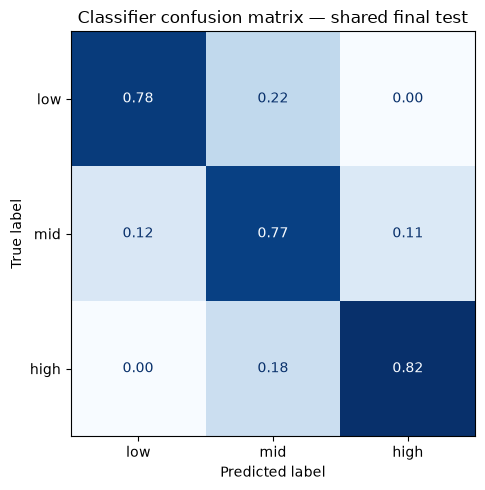

In [9]:
y_class_test = classification_splits["y_test"].reshape(-1).astype(int)
y_class_pred = predict_ordinal_classifier(
    classifier,
    classification_splits["X_test_trans"],
)

classifier_accuracy = accuracy_score(
    y_class_test,
    y_class_pred,
)
classifier_test_performance = pd.DataFrame(
    {
        "model": ["Ordinal classifier"],
        "metric": ["Accuracy"],
        "score": [classifier_accuracy],
        "unit": ["proportion correct"],
        "test rows": [len(y_class_test)],
    }
)
display(classifier_test_performance)

fig, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_class_test,
    y_class_pred,
    display_labels=["low", "mid", "high"],
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Classifier confusion matrix — shared final test")
plt.tight_layout()
plt.show()

## Regressor training and evaluation

In [10]:
development_regression_data = dict(
    zip(
        ("low", "mid", "high"),
        get_data_for_regressors(development_data),
    )
)
final_test_regression_data = dict(
    zip(
        ("low", "mid", "high"),
        get_data_for_regressors(final_test_data),
    )
)

regression_scalers = {
    "low": MinMaxScaler(),
    "mid": MinMaxScaler(),
    "high": MinMaxScaler(),
}
regression_losses = {
    "low": quantile_loss_lower,
    "mid": keras.losses.Huber(delta=1.0),
    "high": quantile_loss_upper,
}
regression_model_names = {
    "low": "low_fat_residuals_regressor_final",
    "mid": "mid_fat_boundary_weighted_residuals_regressor_final",
    "high": "high_fat_residuals_regressor_final",
}

regressor_splits = {}
base_models = {}
base_predictions = {}
residual_regressors = {}

for fat_class in ("low", "mid", "high"):
    print(f"Training {fat_class}-fat regression pipeline...")

    branch_splits = get_final_holdout_regressor_splits(
        development_data=development_regression_data[fat_class],
        final_test_data=final_test_regression_data[fat_class],
        scaler=regression_scalers[fat_class],
        lower_threshold=quantile_33,
        upper_threshold=quantile_66,
        boundary_weighted=(fat_class == "mid"),
    )
    training_weight = branch_splits.get("sample_weight_train")
    validation_weight = branch_splits.get("sample_weight_val")

    branch_base_model = get_base_model(
        splits=branch_splits,
        sample_weight=training_weight,
    )
    branch_base_predictions = get_base_predictions(
        base_model=branch_base_model,
        splits=branch_splits,
    )
    branch_residual_regressor = train_get_regressor(
        splits=branch_splits,
        residuals=branch_base_predictions,
        name=regression_model_names[fat_class],
        loss_func=regression_losses[fat_class],
        sample_weight=training_weight,
        validation_sample_weight=validation_weight,
    )

    regressor_splits[fat_class] = branch_splits
    base_models[fat_class] = branch_base_model
    base_predictions[fat_class] = branch_base_predictions
    residual_regressors[fat_class] = branch_residual_regressor

regression_split_sizes = pd.DataFrame(
    {
        fat_class: {
            "train": len(regressor_splits[fat_class]["y_train"]),
            "validation": len(regressor_splits[fat_class]["y_val"]),
            "shared final test": len(
                regressor_splits[fat_class]["y_test"]
            ),
        }
        for fat_class in ("low", "mid", "high")
    }
).T
display(regression_split_sizes)

Training low-fat regression pipeline...
Training mid-fat regression pipeline...
Training high-fat regression pipeline...


,train,validation,shared final test
low,5346,594,648
mid,5346,594,661
high,5508,612,691


In [11]:
regressor_prediction_results = {}
regressor_performance_rows = []

for fat_class in ("low", "mid", "high"):
    branch_splits = regressor_splits[fat_class]
    y_true = branch_splits["y_test"].reshape(-1)

    base_prediction = np.asarray(
        base_models[fat_class].predict(
            branch_splits["X_test_trans"]
        )
    ).reshape(-1)
    residual_prediction = residual_regressors[fat_class].predict(
        branch_splits["X_test_trans"],
        verbose=0,
    ).reshape(-1)
    final_prediction = base_prediction + residual_prediction

    branch_mae = mean_absolute_error(
        y_true,
        final_prediction,
    )
    regressor_prediction_results[fat_class] = {
        "actual": y_true,
        "predicted": final_prediction,
    }
    regressor_performance_rows.append(
        {
            "model": f"{fat_class.title()}-fat hybrid regressor",
            "metric": "MAE",
            "score": branch_mae,
            "unit": "body-fat percentage points",
            "test rows": len(y_true),
        }
    )

regressor_test_performance = pd.DataFrame(
    regressor_performance_rows
)
display(regressor_test_performance)


,model,metric,score,unit,test rows
0,Low-fat hybrid regressor,MAE,1.568914,body-fat percentage points,648
1,Mid-fat hybrid regressor,MAE,0.942137,body-fat percentage points,661
2,High-fat hybrid regressor,MAE,1.267604,body-fat percentage points,691


## Combined pipeline evaluation

All rows are from the shared outer holdout. They were not used to learn class
thresholds, fit scalers, or train any classifier, base model, or residual model.

In [12]:
CLASS_ID_TO_NAME = {0: "low", 1: "mid", 2: "high"}

combined_X = add_engineered_features(
    final_test_data.drop(columns=["fat_percentage", "class"])
)
combined_actual_class = final_test_data[
    "class"
].to_numpy().astype(int)
combined_actual_fat = final_test_data[
    "fat_percentage"
].to_numpy()

combined_classifier_X = classification_scaler.transform(
    combined_X.to_numpy()
)
combined_predicted_class = predict_ordinal_classifier(
    classifier,
    combined_classifier_X,
)

combined_prediction_raw = np.empty(len(combined_X))

for class_id, fat_class in CLASS_ID_TO_NAME.items():
    route_mask = combined_predicted_class == class_id
    if not np.any(route_mask):
        continue

    routed_X = regression_scalers[fat_class].transform(
        combined_X.to_numpy()[route_mask]
    )
    routed_base = np.asarray(
        base_models[fat_class].predict(routed_X)
    ).reshape(-1)
    routed_residual = residual_regressors[fat_class].predict(
        routed_X,
        verbose=0,
    ).reshape(-1)
    combined_prediction_raw[route_mask] = (
        routed_base + routed_residual
    )

combined_prediction = combined_prediction_raw.copy()

combined_results = pd.DataFrame(
    {
        "actual class": [
            CLASS_ID_TO_NAME[value]
            for value in combined_actual_class
        ],
        "predicted class": [
            CLASS_ID_TO_NAME[value]
            for value in combined_predicted_class
        ],
        "actual fat": combined_actual_fat,
        "predicted fat": combined_prediction,
    }
)

In [13]:
final_combined_mae = mean_absolute_error(
    combined_actual_fat,
    combined_prediction,
)
combined_pipeline_performance = pd.DataFrame(
    {
        "model": ["Complete classifier-routed pipeline"],
        "metric": ["MAE"],
        "score": [final_combined_mae],
        "unit": ["body-fat percentage points"],
        "test rows": [len(combined_actual_fat)],
    }
)

final_test_performance_summary = pd.concat(
    [
        classifier_test_performance,
        regressor_test_performance,
        combined_pipeline_performance,
    ],
    ignore_index=True,
)

random_prediction_sample_10 = combined_results.sample(
    n=10,
    random_state=SEED,
).reset_index(drop=True).round(
    {"actual fat": 3, "predicted fat": 3}
)

print("FINAL TEST PERFORMANCE")
display(final_test_performance_summary)

print(
    f"Final combined pipeline MAE: "
    f"{final_combined_mae:.4f} body-fat percentage points"
)

print("Random sample of 10 final-test predictions")
display(random_prediction_sample_10)


FINAL TEST PERFORMANCE


,model,metric,score,unit,test rows
0,Ordinal classifier,Accuracy,0.789000,proportion correct,2000
1,Low-fat hybrid regressor,MAE,1.568914,body-fat percentage points,648
2,Mid-fat hybrid regressor,MAE,0.942137,body-fat percentage points,661
3,High-fat hybrid regressor,MAE,1.267604,body-fat percentage points,691
4,Complete classifier-routed pipeline,MAE,1.828732,body-fat percentage points,2000


Final combined pipeline MAE: 1.8287 body-fat percentage points
Random sample of 10 final-test predictions


,actual class,predicted class,actual fat,predicted fat
0,high,high,34.592,33.064
1,high,mid,28.620,25.570
2,high,high,28.312,33.320
3,high,mid,28.197,26.523
4,low,low,15.330,17.520
5,high,high,30.237,31.221
6,mid,mid,27.013,26.201
7,high,high,28.640,32.505
8,mid,mid,27.477,26.678
9,mid,low,24.572,20.808


## Save final artifacts

In [14]:
if SAVE_ARTIFACTS:
    for artifact_type in (
        "classifiers",
        "regressors",
        "base_models",
        "scalers",
    ):
        (MODELS_PATH / artifact_type).mkdir(parents=True, exist_ok=True)

    save_model(
        classifier,
        MODELS_PATH
        / "classifiers"
        / "fat_percentage_ordinal_classifier_final.keras",
    )
    save_scaler(
        classification_scaler,
        MODELS_PATH / "scalers" / "classification_scaler_final.pkl",
    )

    for fat_class in ("low", "mid", "high"):
        save_base_model_pkl(
            base_models[fat_class],
            MODELS_PATH
            / "base_models"
            / f"{fat_class}_fat_base_model_final.pkl",
        )
        save_model(
            residual_regressors[fat_class],
            MODELS_PATH
            / "regressors"
            / f"{regression_model_names[fat_class]}.keras",
        )
        save_scaler(
            regression_scalers[fat_class],
            MODELS_PATH
            / "scalers"
            / f"{fat_class}_fat_scaler_final.pkl",
        )

    print(f"Models and scalers saved under: {MODELS_PATH}")
else:
    print("SAVE_ARTIFACTS is False.")

SAVE_ARTIFACTS is False.


## Export evaluation evidence

In [15]:
if EXPORT_EVIDENCE:
    EVIDENCE_PATH.mkdir(parents=True, exist_ok=True)

    final_test_performance_summary.to_csv(
        EVIDENCE_PATH / "final_test_performance_summary.csv",
        index=False,
    )
    combined_results.to_csv(
        EVIDENCE_PATH / "final_combined_predictions.csv",
        index=False,
    )
    random_prediction_sample_10.to_csv(
        EVIDENCE_PATH / "random_prediction_sample_10.csv",
        index=False,
    )

    print(f"Final evaluation evidence exported to: {EVIDENCE_PATH}")
else:
    print(
        "EXPORT_EVIDENCE is False. Set it to True to export the "
        "final summary and prediction evidence."
    )


EXPORT_EVIDENCE is False. Set it to True to export the final summary and prediction evidence.
